In [4]:
import matplotlib.pyplot as plt
import numpy as np
import common
from dataclasses import dataclass
from typing import List, Tuple

In [5]:
%config InlineBackend.figure_format = 'retina'

In [6]:
@dataclass
class LinePlotData:
    x: List[float]
    y: List[float]
    name: str

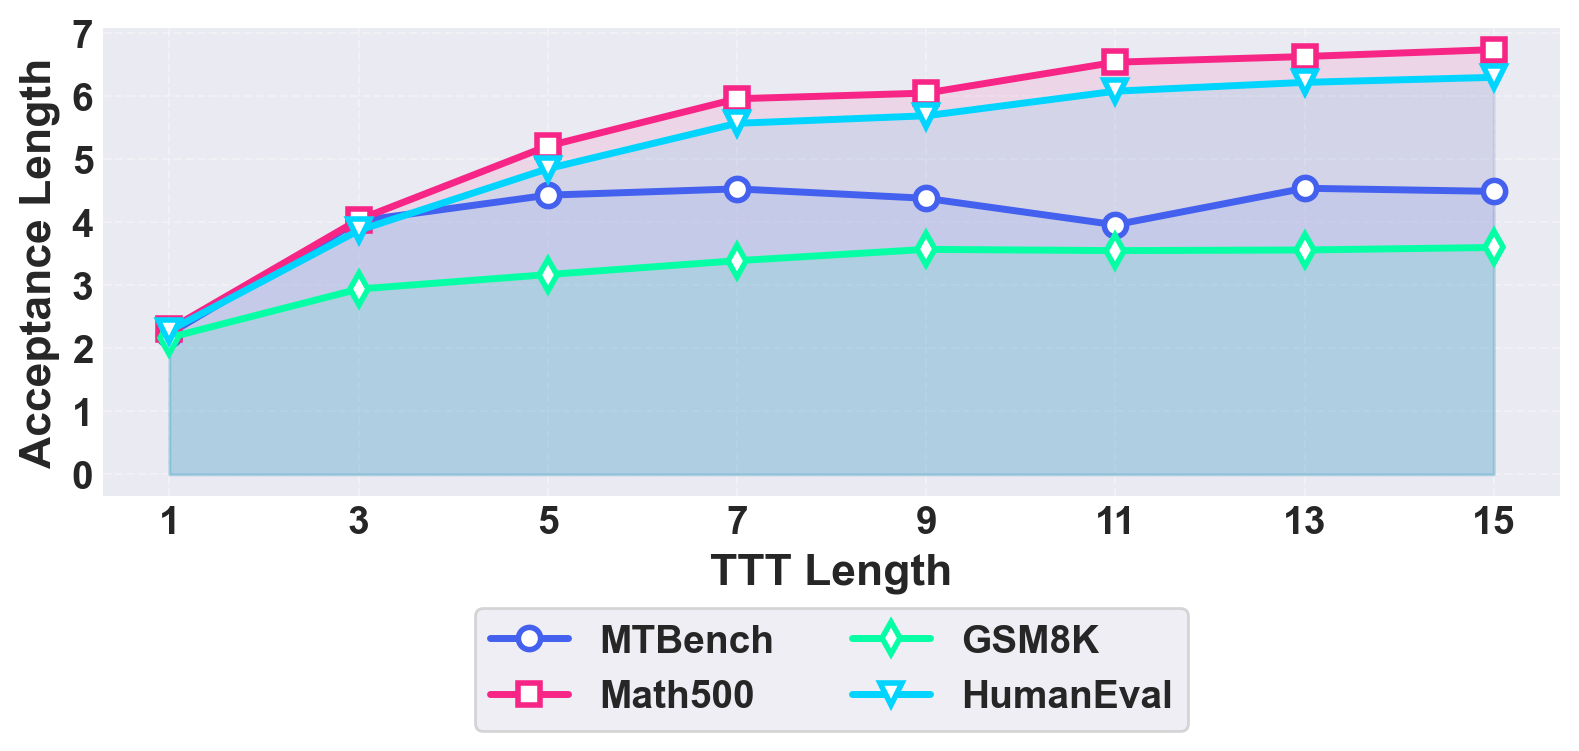

In [8]:
def generate_line_plot(
    data_list: List[LinePlotData], 
    x_label: str, 
    y_label: str, 
    title: str,
    x_ticks: Tuple[List[int], List[str]],
    show_legend: bool = True, 
    show_grid: bool = True, 
    num_legend_cols: int = 2,
    show_area_under_curve: bool = False,
    ):

    # set the size to be 12x8
    plt.figure(figsize=(8, 4))

    for idx, line_data in enumerate(data_list):
        plt.plot(
                line_data.x, 
                line_data.y, 
                marker=common.MARKERS[idx], 
                linewidth=common.LINE_WIDTH, 
                markersize=common.MARKER_SIZE, 
                color=common.COLORS[idx], 
                label=line_data.name, 
                markerfacecolor=common.MARKERFACECOLOR, 
                markeredgewidth=common.MARKEREDGEWIDTH, 
                markeredgecolor=common.COLORS[idx]
                )

        if show_area_under_curve:
            plt.fill_between(line_data.x, line_data.y, alpha=0.1, color=common.COLORS[idx])

    plt.xlabel(x_label, fontsize=common.LABEL_FONT_SIZE, fontweight='bold')
    plt.ylabel(y_label, fontsize=common.LABEL_FONT_SIZE, fontweight='bold')
    
    plt.xticks(fontsize=common.X_TICK_FONT_SIZE, fontweight='bold')
    plt.yticks(fontsize=common.Y_TICK_FONT_SIZE, fontweight='bold')

    if title:
        plt.title(title, fontsize=common.TITLE_SIZE, fontweight='bold', pad=20)

    if x_ticks:
        plt.xticks(x_ticks[0], x_ticks[1], fontsize=common.X_TICK_FONT_SIZE)

    if show_legend:
        # put legend below the plot
        plt.legend(frameon=True, loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=2, prop={'weight': 'bold', 'size': 14})

    if show_grid:
        plt.grid(True, alpha=0.3, linestyle='--')

    plt.tight_layout()


# Generate sample data
months = ['1', '3', '5', '7', '9', '11', '13', '15']
data_list = [
        LinePlotData(x=[0, 1, 2, 3, 4, 5, 6, 7], y=[2.23, 4.02, 4.43, 4.53, 4.38, 3.96, 4.54, 4.49], name='MTBench'),
        LinePlotData(x=[0, 1, 2, 3, 4, 5, 6, 7], y=[2.30, 4.04, 5.21, 5.96, 6.05, 6.54, 6.63, 6.74], name='Math500'),
        LinePlotData(x=[0, 1, 2, 3, 4, 5, 6, 7], y=[2.17, 2.94, 3.17, 3.39, 3.57, 3.55, 3.56, 3.60], name='GSM8K'),
        LinePlotData(x=[0, 1, 2, 3, 4, 5, 6, 7], y=[2.28, 3.87, 4.85, 5.57, 5.69, 6.08, 6.22, 6.30], name='HumanEval'),
]


generate_line_plot(
        data_list=data_list,
        x_label='TTT Length',
        y_label='Acceptance Length',
        title=None,
        x_ticks=[
            list(range(len(months))),
            months
        ],
        show_legend=True,
        show_grid=True,
        show_area_under_curve=True
)
plt.savefig('plots/training-time-test.pdf', dpi=300)
plt.show()